# GoogLeNet (Inception v1)

## Overview

GoogLeNet, also known as Inception v1, was introduced by Google in 2014. It won the ImageNet Large Scale Visual Recognition Challenge (ILSVRC) 2014 by achieving high accuracy with significantly fewer parameters than previous deep CNNs.

## Key Features

- Introduced the Inception module.
- Performs multiple convolution operations in parallel.
- Uses 1×1 convolutions for dimensionality reduction.
- Contains 22 learnable layers.
- Efficient in terms of computation and memory.

## Architecture Summary

Input Image
→ Convolution Layers
→ Inception Modules
→ Auxiliary Classifiers
→ Global Average Pooling
→ Output Layer

## Applications

- Image classification
- Object detection
- Transfer learning
- Feature extraction

## Limitations

- More complex architecture than previous CNNs.
- Difficult to implement from scratch.
- Parallel branches increase implementation complexity.

In [1]:
import numpy as np
import pandas as pd

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, Flatten, Input, concatenate, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam

import matplotlib.pyplot as plt
import sklearn

import warnings
warnings.filterwarnings('ignore')

In [2]:
train_dir = "HAR3Class/train"
test_dir = "HAR3Class/test"

train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True)

test_datagen = ImageDataGenerator(rescale = 1.0/255)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size = (224, 224),
    batch_size = 32, # no of images to be read at once
    class_mode = 'categorical'
) ## assigns labels based on folder names.


test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size = (224, 224),
    batch_size = 32, # no of images to be read at once
    class_mode = 'categorical'
) 

## here if i put target_size = (227,227), then it will automatically resize the images, but not pad it

Found 610 images belonging to 3 classes.


Found 150 images belonging to 3 classes.


In [3]:
def inception_block(x, f1, f3_r, f3, f5_r, f5, proj):

    path1 = Conv2D(f1, (1,1), padding='same', activation='relu')(x)

    path2 = Conv2D(f3_r, (1,1), padding='same', activation='relu')(x)
    path2 = Conv2D(f3, (3,3), padding='same', activation='relu')(path2)

    path3 = Conv2D(f5_r, (1,1), padding='same', activation='relu')(x)
    path3 = Conv2D(f5, (5,5), padding='same', activation='relu')(path3)

    path4 = MaxPooling2D((3,3), strides=(1,1), padding='same')(x)
    path4 = Conv2D(proj, (1,1), padding='same', activation='relu')(path4)

    return concatenate([path1, path2, path3, path4])


input_shape = (224,224,3)
num_classes = 3

input_layer = Input(shape=input_shape)

x = Conv2D(64,(7,7),strides=2,padding='same',activation='relu')(input_layer)
x = MaxPooling2D((3,3),strides=2,padding='same')(x)

x = Conv2D(64,(1,1),activation='relu')(x)
x = Conv2D(192,(3,3),padding='same',activation='relu')(x)
x = MaxPooling2D((3,3),strides=2,padding='same')(x)

x = inception_block(x,64,96,128,16,32,32)
x = inception_block(x,128,128,192,32,96,64)

x = MaxPooling2D((3,3),strides=2,padding='same')(x)

x = inception_block(x,192,96,208,16,48,64)

x = GlobalAveragePooling2D()(x)
x = Dropout(0.4)(x)

output = Dense(num_classes, activation='softmax')(x)

googlenet_model = Model(inputs=input_layer, outputs=output)


## Not adding layers as it is a functional model, not a Sequential

In [4]:
googlenet_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [5]:
history = googlenet_model.fit(train_data, validation_data = test_data, epochs=10)

## sparse categorical crossentropy is for 0,1,2,3....
## categorical cross entropy is for one hot encoded variables

 1/20 ━━━━━━━━━━━━━━━━━━━━ 13:00 41s/step - accuracy: 0.4375 - loss: 1.0863

 2/20 ━━━━━━━━━━━━━━━━━━━━ 59s 3s/step - accuracy: 0.4297 - loss: 1.0934   

 3/20 ━━━━━━━━━━━━━━━━━━━━ 59s 3s/step - accuracy: 0.4184 - loss: 1.0990

 4/20 ━━━━━━━━━━━━━━━━━━━━ 57s 4s/step - accuracy: 0.4134 - loss: 1.1007

 5/20 ━━━━━━━━━━━━━━━━━━━━ 57s 4s/step - accuracy: 0.4045 - loss: 1.1019

...

17/20 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.3378 - loss: 1.0991

18/20 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.3371 - loss: 1.0991

19/20 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.3363 - loss: 1.0991

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3357 - loss: 1.0992

20/20 ━━━━━━━━━━━━━━━━━━━━ 32s 2s/step - accuracy: 0.3246 - loss: 1.0997 - val_accuracy: 0.3333 - val_loss: 1.0988


<Axes: >

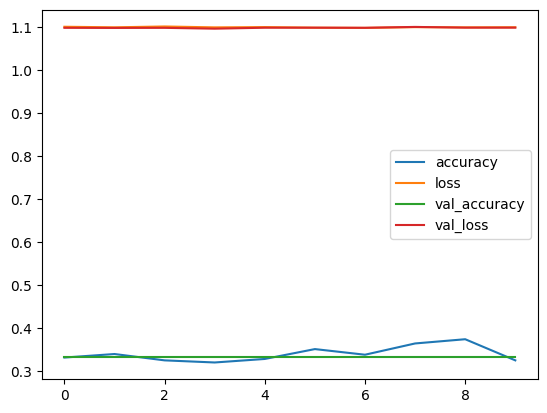

In [6]:
pd.DataFrame(history.history).plot()